In [16]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from thesis.config import GroupingConfig
from thesis.configs import dataset_for_scenario
from thesis.experiments._shared import load_scenario_context
from thesis.features.persistence import load_symbolic_feature_schema
from thesis.grouping.group_alerts import CSCAS_PREGROUPED_METHOD
from thesis.mining.window_schema_cache import get_or_mine_window_attribute_schema
from thesis.paths import ARTIFACTS_DIR
from thesis.scripts.mining._common import cache_dir_for

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Settings

Edit and re-run -- nothing past this cell needs to change. `FILTERED`/`WINDOW_SIZE`
must match whatever the Screening Sweep run itself used (defaults here match
`run_screening_sweep.py`'s own defaults) -- they determine which cached
`alert_groups` file is resolved, which must line up for schema cache lookups
to hit.

In [17]:
SCENARIO = "cscas"
RUN_ID = None  # None -> latest screening_sweep run dir for SCENARIO

FILTERED = None  # AIT-ADS only: balancing method, e.g. "naive50" -- None for cscas
WINDOW_SIZE = 2

PRIMARY_METRIC = "auc"
LINE_COLOR = "#4477AA"

# Near-duplicate detection: two mining settings are flagged as near-duplicate
# if PRIMARY_METRIC matches within this tolerance at every window_id they're
# both evaluated on, within a granularity. Looser than temporal_decay_eda's
# 1e-6: there, one frozen model is scored on every horizon, so an exact match
# at h=0 propagates exactly. Here every window mines and fits independently,
# so even when the same "extra features are irrelevant" phenomenon holds,
# tiny mining nondeterminism (near-tied candidate itemsets resolved
# differently window to window) shows up as ~1e-5-scale noise on top of it --
# still two orders of magnitude tighter than any practically meaningful AUC
# difference.
ATOL = 1e-4

# Which near-duplicate pair (row index into `near_dupes`, section 2) to
# inspect in section 3 -- set after seeing that table.
PAIR_SELECT = 0

In [18]:
sweep_dir = ARTIFACTS_DIR / "experiments" / "screening_sweep" / SCENARIO
run_dir = (
    sweep_dir / RUN_ID if RUN_ID
    else sorted(p for p in sweep_dir.iterdir() if p.is_dir())[-1]
)

per_window = pd.read_csv(run_dir / "per_window_results.csv")

raw_config = pd.read_json(run_dir / "config.json", typ="series")
TRAIN_FRAC = float(raw_config["train_frac_within_window"])
MINING_SETTINGS_PATH = Path(raw_config["mining_settings_path"])

print(f"Loaded from {run_dir}")
print(f"per_window_results: {len(per_window)} rows")
print(f"train_frac_within_window={TRAIN_FRAC}, mining_settings_path={MINING_SETTINGS_PATH}")
per_window.head()

Loaded from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/screening_sweep/cscas/20260713_192514
per_window_results: 147 rows
train_frac_within_window=0.7, mining_settings_path=/Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/configs/screening_mining_settings.yaml


,scenario,granularity,window_id,win_start_frac,win_end_frac,n_alert_groups,n_attack,n_train,n_test,feature_set,mining_setting,model,n_features,auc,f1,accuracy,precision,recall,tp,fp,tn,fn,single_class_split,mining_cache_hit
0,cscas,0.1,2,0.199999,0.299999,139532,1810,97672,41860,baseline,NaN,logreg,41,0.998727,0.827692,0.994649,0.718291,0.976407,538,211,41098,13,False,NaN
1,cscas,0.1,2,0.199999,0.299999,139532,1810,97672,41860,symbolic,gr3_md1_mda2,logreg,355,0.998959,0.856006,0.995676,0.762040,0.976407,538,168,41141,13,False,True
2,cscas,0.1,2,0.199999,0.299999,139532,1810,97672,41860,symbolic,gr3_md1_mda3,logreg,355,0.997869,0.856688,0.995700,0.763121,0.976407,538,167,41142,13,False,True
3,cscas,0.1,2,0.199999,0.299999,139532,1810,97672,41860,symbolic,gr3_md1_mda4,logreg,355,0.996156,0.852615,0.995557,0.756681,0.976407,538,173,41136,13,False,True
4,cscas,0.1,2,0.199999,0.299999,139532,1810,97672,41860,symbolic,gr3_md2_mda2,logreg,356,0.981059,0.857371,0.995724,0.764205,0.976407,538,166,41143,13,False,True


In [19]:
is_cscas = dataset_for_scenario(SCENARIO) == "cscas"
grouping = (
    GroupingConfig(mode=CSCAS_PREGROUPED_METHOD)
    if is_cscas
    else GroupingConfig(window_size=WINDOW_SIZE)
)
cache_dir = cache_dir_for(SCENARIO, FILTERED is not None, FILTERED, WINDOW_SIZE)

# Full scenario load, once -- needed even for cache-hit schema lookups, since
# get_or_mine_window_attribute_schema needs len(alert_groups) to resolve
# window bounds. Nothing here re-mines; every schema load below is a cache
# read against the Screening Sweep run's own mining output.
ctx = load_scenario_context(
    scenario=SCENARIO,
    cache_dir=cache_dir,
    grouping=grouping,
    alerts_json_path=None,
    mining_settings_path=MINING_SETTINGS_PATH,
)


def load_schema_for(mining_setting: str, gran: float, win_idx: int):
    # mining_settings_path resolves against the *current* file on disk, not a
    # frozen copy from when this run's sweep actually executed -- if that file
    # has since been edited (e.g. configs/screening_mining_settings.yaml swapped
    # to a new shortlist), a setting name from an older run's results can be
    # legitimately absent now. Raise something callers can catch and skip,
    # rather than a bare KeyError.
    if mining_setting not in ctx.mining_settings_by_name:
        raise ValueError(
            f"'{mining_setting}' is not in {MINING_SETTINGS_PATH.name} as currently written "
            f"({sorted(ctx.mining_settings_by_name)}) -- this run's results predate that file's "
            "current contents. Re-run the sweep against the current yaml, or point RUN_ID at a "
            "run made after it, to get a schema lookup that matches."
        )
    spec = ctx.mining_settings_by_name[mining_setting]
    res = get_or_mine_window_attribute_schema(
        scenario=SCENARIO,
        alert_groups=ctx.alert_groups,
        alert_groups_path=ctx.alert_groups_path,
        gran=gran,
        win_idx=win_idx,
        attribute_mining_config=spec.to_attribute_mining_config(),
        train_frac=TRAIN_FRAC,
        force=False,
    )
    return load_symbolic_feature_schema(res.schema_path), res.cache_hit


[ScenarioContext] Scenario: 'cscas'
[1/4] Ingesting scenario...
  [skip] alert_groups already exist at /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
[2/4] Checking feature manifest...
  [skip] Feature manifest already exists at /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/features/cscas/manifest.json
[3/4] Building alert_groups from cache...
  [skip] Loading alert_groups from existing /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json
  Loaded 1395324 alert_groups from cache.
  1395324 alert_groups total


## 1. Does mined schema size correlate with performance?

`n_features` and the metric are already both in `per_window_results.csv`
(no schema reload needed for this section) -- one point per (mining_setting,
granularity, window) evaluation, colored by granularity. Spearman rather
than Pearson, since the question is "does more features rank higher", not
"is the relationship linear".

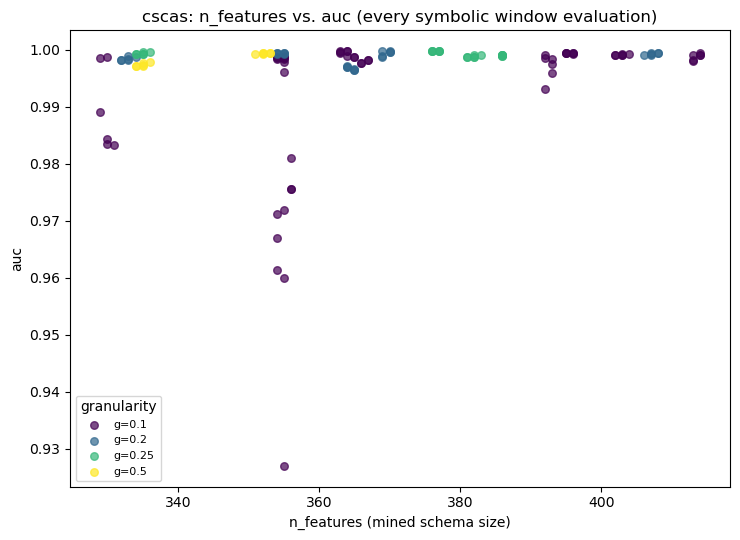

In [20]:
symbolic = per_window[per_window["feature_set"] == "symbolic"].copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
grans = sorted(symbolic["granularity"].unique())
cmap = plt.get_cmap("viridis")
for i, gran in enumerate(grans):
    sub = symbolic[symbolic["granularity"] == gran]
    color = cmap(i / max(1, len(grans) - 1))
    ax.scatter(sub["n_features"], sub[PRIMARY_METRIC], label=f"g={gran:g}", color=color, alpha=0.7, s=30)

ax.set_xlabel("n_features (mined schema size)")
ax.set_ylabel(PRIMARY_METRIC)
ax.set_title(f"{SCENARIO}: n_features vs. {PRIMARY_METRIC} (every symbolic window evaluation)")
ax.legend(title="granularity", fontsize=8)
fig.tight_layout()

In [21]:
corr_rows = []
for gran, g in symbolic.groupby("granularity"):
    if g["n_features"].nunique() < 2 or g[PRIMARY_METRIC].notna().sum() < 2:
        continue
    rho, p = spearmanr(g["n_features"], g[PRIMARY_METRIC], nan_policy="omit")
    corr_rows.append({"granularity": gran, "n_rows": len(g), "spearman_n_features_vs_metric": rho, "p_value": p})

rho_all, p_all = spearmanr(symbolic["n_features"], symbolic[PRIMARY_METRIC], nan_policy="omit")
print(f"Overall (all granularities pooled): spearman={rho_all:.3f}, p={p_all:.3g}")
pd.DataFrame(corr_rows)

Overall (all granularities pooled): spearman=0.291, p=0.000941


,granularity,n_rows,spearman_n_features_vs_metric,p_value
0,0.10,60,0.531790,0.000012
1,0.20,30,0.401745,0.027764
2,0.25,24,-0.589384,0.002440
3,0.50,12,0.932532,0.000010


## 2. Near-duplicate mining settings

Same check as `temporal_decay_eda.ipynb`'s near-duplicate detector, adapted
to Screening Sweep's shape: pairs of `mining_setting` whose `PRIMARY_METRIC`
matches within `ATOL` at every `window_id` they're both evaluated on --
**within a granularity** (settings can behave identically at one window size
and diverge at another, so this is checked per granularity, not pooled
across the whole grid) -- across every window Experiment 1 evaluated, not
just window 0.

In [22]:
def find_near_duplicate_settings(df: pd.DataFrame, metric: str, atol: float) -> pd.DataFrame:
    rows = []
    for gran, g in df.groupby("granularity"):
        pivot = g.pivot_table(index="window_id", columns="mining_setting", values=metric)
        settings = list(pivot.columns)
        for i in range(len(settings)):
            for j in range(i + 1, len(settings)):
                a, b = pivot[settings[i]], pivot[settings[j]]
                shared = a.notna() & b.notna()
                if shared.sum() == 0:
                    continue
                diff = (a[shared] - b[shared]).abs()
                if diff.max() <= atol:
                    rows.append({
                        "granularity": gran,
                        "setting_a": settings[i],
                        "setting_b": settings[j],
                        "n_shared_windows": int(shared.sum()),
                        "max_abs_diff": float(diff.max()),
                    })
    return pd.DataFrame(rows)


near_dupes = find_near_duplicate_settings(symbolic, PRIMARY_METRIC, ATOL)
if near_dupes.empty:
    print(f"No mining_setting pairs with identical {PRIMARY_METRIC} (within {ATOL}) at every shared window.")
else:
    print(f"{len(near_dupes)} near-duplicate (granularity, mining_setting pair) row(s) found:")
near_dupes

5 near-duplicate (granularity, mining_setting pair) row(s) found:


,granularity,setting_a,setting_b,n_shared_windows,max_abs_diff
0,0.25,gr3_md1_mda2,gr3_md2_mda2,4,0.000036
1,0.25,gr3_md1_mda3,gr3_md2_mda3,4,0.000029
2,0.25,gr3_md1_mda4,gr3_md2_mda4,4,0.000020
3,0.50,gr3_md1_mda2,gr3_md2_mda2,2,0.000088
4,0.50,gr3_md1_mda3,gr3_md2_mda3,2,0.000025


## 3. Why don't the extra features change performance?

For the pair selected by `PAIR_SELECT` above, load both settings' actual
mined schemas (cache reads, via `load_schema_for`) at the `(granularity,
window_id)` where their feature counts diverge most -- the sharpest case for
this pair -- and diff them by `(itemset, mining_type, source_label)` identity.

Two competing explanations would both produce "extra features, unchanged
performance": (a) the extra features are individually weak (low support,
low attack/benign confidence gap) and a regularized model shrinks them
toward irrelevance, or (b) they're individually fine but *redundant* with
features already in the shared set (multicollinearity), so a regularized
model doesn't need them to reach the same decision function either way. The
table below checks (a) directly. On real data this often does **not**
confirm (a) -- extra features frequently have *higher* median support/
confidence gap than the shared ones, which rules out "just weak" as the
general explanation and points toward (b) instead. `utility_score` is
included for completeness but has come out constant (1.0) for every feature
seen so far in this mining path -- not informative, not a bug in this
notebook.

In [23]:
schema_a = schema_b = None
only_in_a = only_in_b = shared_keys = None


def feature_key(f):
    return (f.itemset, f.mining_type, f.source_label)


if near_dupes.empty:
    print("No near-duplicate pairs to inspect -- skip section 3.")
else:
    pair = near_dupes.iloc[PAIR_SELECT]
    setting_a, setting_b, gran_sel = pair["setting_a"], pair["setting_b"], pair["granularity"]

    cand = symbolic[
        (symbolic["granularity"] == gran_sel) & symbolic["mining_setting"].isin([setting_a, setting_b])
    ]
    feat_pivot = cand.pivot_table(index="window_id", columns="mining_setting", values="n_features")
    feat_pivot = feat_pivot.dropna(subset=[setting_a, setting_b])
    feat_pivot["feature_diff"] = (feat_pivot[setting_a] - feat_pivot[setting_b]).abs()
    win_sel = feat_pivot["feature_diff"].idxmax()

    n_a = int(feat_pivot.loc[win_sel, setting_a])
    n_b = int(feat_pivot.loc[win_sel, setting_b])
    print(
        f"Pair {PAIR_SELECT}: '{setting_a}' (n_features={n_a}) vs '{setting_b}' (n_features={n_b}) "
        f"at granularity={gran_sel:g}, window_id={int(win_sel)}"
    )

    try:
        schema_a, hit_a = load_schema_for(setting_a, gran_sel, int(win_sel))
        schema_b, hit_b = load_schema_for(setting_b, gran_sel, int(win_sel))
        print(f"  loaded '{setting_a}': {len(schema_a.features)} features (cache_hit={hit_a})")
        print(f"  loaded '{setting_b}': {len(schema_b.features)} features (cache_hit={hit_b})")

        keys_a = {feature_key(f): f for f in schema_a.features}
        keys_b = {feature_key(f): f for f in schema_b.features}

        shared_keys = keys_a.keys() & keys_b.keys()
        only_in_a = [keys_a[k] for k in keys_a.keys() - keys_b.keys()]
        only_in_b = [keys_b[k] for k in keys_b.keys() - keys_a.keys()]

        print(f"  shared features: {len(shared_keys)}")
        print(f"  only in '{setting_a}': {len(only_in_a)}")
        print(f"  only in '{setting_b}': {len(only_in_b)}")
    except ValueError as exc:
        print(f"  [skip] {exc}")
        schema_a = schema_b = None

Pair 0: 'gr3_md1_mda2' (n_features=334) vs 'gr3_md2_mda2' (n_features=335) at granularity=0.25, window_id=0
  loaded 'gr3_md1_mda2': 293 features (cache_hit=True)
  loaded 'gr3_md2_mda2': 294 features (cache_hit=True)
  shared features: 293
  only in 'gr3_md1_mda2': 0
  only in 'gr3_md2_mda2': 1


In [24]:
def stats_table(features, label: str) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "group": label,
            "mining_type": f.mining_type,
            "support": f.support,
            "confidence_attack": f.confidence_attack,
            "confidence_benign": f.confidence_benign,
            "confidence_gap": (
                abs(f.confidence_attack - f.confidence_benign)
                if f.confidence_attack is not None and f.confidence_benign is not None
                else None
            ),
            "utility_score": f.utility_score,
        }
        for f in features
    ])


if schema_a is not None:
    all_stats = pd.concat(
        [
            stats_table([keys_a[k] for k in shared_keys], "shared"),
            stats_table(only_in_a, f"only in {setting_a}"),
            stats_table(only_in_b, f"only in {setting_b}"),
        ],
        ignore_index=True,
    )
    display(all_stats.groupby("group")[["support", "confidence_gap", "utility_score"]].describe().T)

group                 only in gr3_md2_mda2      shared
support        count              1.000000  293.000000
               mean               0.002523    0.109545
               std                     NaN    0.134946
               min                0.002523    0.000594
               25%                0.002523    0.017094
               50%                0.002523    0.082344
               75%                0.002523    0.186476
               max                0.002523    0.979728
confidence_gap count              1.000000  293.000000
               mean               0.002553    0.320776
               std                     NaN    0.267128
               min                0.002553    0.038724
               25%                0.002553    0.112605
               50%                0.002553    0.171387
               75%                0.002553    0.649616
               max                0.002553    0.993880
utility_score  count              1.000000  293.000000
               mean               1.000000    1.000000
               std                     NaN    0.000000
               min                1.000000    1.000000
               25%                1.000000    1.000000
               50%                1.000000    1.000000
               75%                1.000000    1.000000
               max                1.000000    1.000000

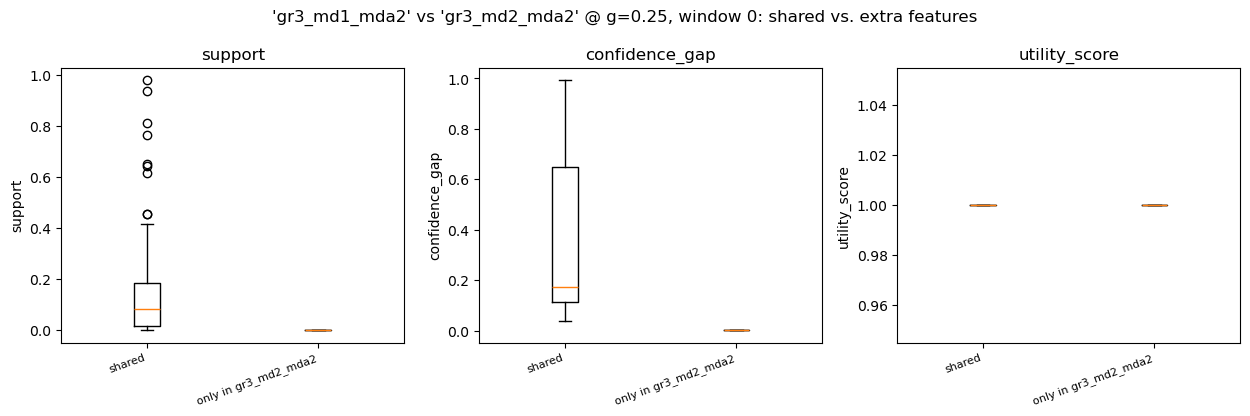

In [25]:
if schema_a is not None:
    cols = ["support", "confidence_gap", "utility_score"]
    groups = ["shared", f"only in {setting_a}", f"only in {setting_b}"]
    groups = [g for g in groups if g in all_stats["group"].unique()]

    fig, axes = plt.subplots(1, len(cols), figsize=(4.2 * len(cols), 4.2))
    for ax, col in zip(axes, cols):
        data = [all_stats.loc[all_stats["group"] == g, col].dropna() for g in groups]
        ax.boxplot(data, tick_labels=groups)
        ax.set_ylabel(col)
        ax.set_title(col)
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
    fig.suptitle(f"'{setting_a}' vs '{setting_b}' @ g={gran_sel:g}, window {int(win_sel)}: shared vs. extra features")
    fig.tight_layout()
else:
    print("Nothing to plot -- no near-duplicate pair was selected.")

## 4. Does the "extra features are weaker" pattern hold across every pair?

Repeats section 3's diff (at each pair's biggest-feature-gap window) for
every row in `near_dupes`, without needing to hand-pick `PAIR_SELECT` each
time -- one row per pair, comparing the median support/utility_score of the
features unique to the larger schema against the features both settings
share. If `extra_weaker_by_support` were `True` almost everywhere, that
would confirm explanation (a) from section 3 (extras are just individually
weak). In practice this comes out mixed -- roughly half `True`, half
`False` -- which rules out (a) as the general explanation and leaves
redundancy/multicollinearity with the shared features (b) as the more
likely one; confirming (b) directly would need checking whether each extra
feature's encoded values correlate with an already-shared feature's, not
just its own mining statistics.

In [26]:
def summarize_pair(setting_a: str, setting_b: str, gran_sel: float) -> dict | None:
    cand = symbolic[
        (symbolic["granularity"] == gran_sel) & symbolic["mining_setting"].isin([setting_a, setting_b])
    ]
    feat_pivot = cand.pivot_table(index="window_id", columns="mining_setting", values="n_features")
    feat_pivot = feat_pivot.dropna(subset=[setting_a, setting_b])
    if feat_pivot.empty:
        return None
    feat_pivot["feature_diff"] = (feat_pivot[setting_a] - feat_pivot[setting_b]).abs()
    win_sel = feat_pivot["feature_diff"].idxmax()

    try:
        s_a, _ = load_schema_for(setting_a, gran_sel, int(win_sel))
        s_b, _ = load_schema_for(setting_b, gran_sel, int(win_sel))
    except ValueError:
        return None

    k_a = {feature_key(f): f for f in s_a.features}
    k_b = {feature_key(f): f for f in s_b.features}
    shared = k_a.keys() & k_b.keys()
    extra = [k_a[k] for k in k_a.keys() - k_b.keys()] + [k_b[k] for k in k_b.keys() - k_a.keys()]
    shared_feats = [k_a[k] for k in shared]

    def median_of(features, attr):
        vals = [getattr(f, attr) for f in features if getattr(f, attr) is not None]
        return float(np.median(vals)) if vals else np.nan

    return {
        "setting_a": setting_a, "setting_b": setting_b,
        "granularity": gran_sel, "window_id": int(win_sel),
        "n_shared": len(shared), "n_extra": len(extra),
        "shared_median_support": median_of(shared_feats, "support"),
        "extra_median_support": median_of(extra, "support"),
        "shared_median_utility": median_of(shared_feats, "utility_score"),
        "extra_median_utility": median_of(extra, "utility_score"),
    }


if near_dupes.empty:
    print("No near-duplicate pairs -- nothing to summarize.")
    pair_summary = pd.DataFrame()
else:
    summary_rows = [
        summarize_pair(r["setting_a"], r["setting_b"], r["granularity"]) for _, r in near_dupes.iterrows()
    ]
    valid_rows = [r for r in summary_rows if r is not None]
    n_skipped = len(summary_rows) - len(valid_rows)
    if n_skipped:
        print(f"  [skip] {n_skipped}/{len(summary_rows)} pairs skipped -- setting name(s) not in the "
              f"current {MINING_SETTINGS_PATH.name} (stale run, see section 3's note)")
    pair_summary = pd.DataFrame(valid_rows)
    if not pair_summary.empty:
        pair_summary["extra_weaker_by_support"] = (
            pair_summary["extra_median_support"] < pair_summary["shared_median_support"]
        )
        pair_summary["extra_weaker_by_utility"] = (
            pair_summary["extra_median_utility"] < pair_summary["shared_median_utility"]
        )
pair_summary

,setting_a,setting_b,granularity,window_id,n_shared,n_extra,shared_median_support,extra_median_support,shared_median_utility,extra_median_utility,extra_weaker_by_support,extra_weaker_by_utility
0,gr3_md1_mda2,gr3_md2_mda2,0.25,0,293,1,0.082344,0.002523,1.0,1.0,True,False
1,gr3_md1_mda3,gr3_md2_mda3,0.25,0,293,1,0.082344,0.002523,1.0,1.0,True,False
2,gr3_md1_mda4,gr3_md2_mda4,0.25,0,294,1,0.082344,0.002523,1.0,1.0,True,False
3,gr3_md1_mda2,gr3_md2_mda2,0.50,0,293,1,0.076034,0.001466,1.0,1.0,True,False
4,gr3_md1_mda3,gr3_md2_mda3,0.50,0,293,1,0.076034,0.001466,1.0,1.0,True,False


## 5. Structural mining metrics vs. real screening performance

Sections 1-4 above work on whatever grid this run evaluated, old or new. This section
is shortlist-specific: it joins each `mining_setting`'s *structural* precision/recall
(`mean_tree_precision_attack`/`mean_tree_recall_benign`, computed purely from mined
leaf statistics in `attribute_mining_sweep_eda.ipynb` section 5.3, exported to
`feasible_configs_all.csv`) against what the *real* screening models (this run's own
`auc`/`f1`) actually did -- checking whether the mining-only ranking that built the
shortlist is trustworthy, and specifically the two claims that ranking was built on:

- `max_depth=2` cleared the recall floor only narrowly and with much higher
  across-window variance than `max_depth=1` (structural `recall_benign` std 0.123 vs.
  0.005) -- does that show up as `max_depth=2` performing worse or less reliably here?
- `max_depth_attack=2` was picked over `=3`/`=4` for having the *lowest* structural
  precision variance, not the highest mean -- does it also have the most stable real
  `auc`/`f1` across windows, or was that argument mining-only and doesn't transfer?

Requires this run to have evaluated `mining_setting` names matching the shortlist
naming convention (`gr{growth_rate:g}_md{max_depth}_mda{max_depth_attack}`) -- an old
run against a different grid (like whatever's currently loaded, if the sweep hasn't
been re-run against the shortlist yet) will show 0 matches below, not an error.

In [27]:
STRUCTURAL_METRICS_PATH = Path(
    "../../../artifacts/experiments/attribute_mining_parameter_grid/feasible_configs_all.csv"
)
structural = pd.read_csv(STRUCTURAL_METRICS_PATH)
structural["mining_setting"] = structural.apply(
    lambda r: f"gr{r['growth_rate']:g}_md{int(r['max_depth'])}_mda{int(r['max_depth_attack'])}", axis=1
)

matched_settings = set(structural["mining_setting"]) & set(symbolic["mining_setting"].dropna())
print(f"{len(matched_settings)}/{len(structural)} shortlist settings found in this run's mining_setting "
      f"column: {sorted(matched_settings)}")
if not matched_settings:
    print(f"\n  No overlap -- this run (mining_settings_path={MINING_SETTINGS_PATH.name}) doesn't match "
          "the shortlist naming convention. Re-run run_screening_sweep.sh against the current "
          "configs/screening_mining_settings.yaml, then re-run this notebook, to populate this section.")

real_perf = (
    symbolic[symbolic["mining_setting"].isin(matched_settings)]
    .groupby("mining_setting")[["auc", "f1"]]
    .agg(["mean", "std", "count"])
)
real_perf.columns = ["_".join(c) for c in real_perf.columns.to_flat_index()]
real_perf = real_perf.reset_index()

joined = structural.merge(real_perf, on="mining_setting", how="inner")
joined

6/6 shortlist settings found in this run's mining_setting column: ['gr3_md1_mda2', 'gr3_md1_mda3', 'gr3_md1_mda4', 'gr3_md2_mda2', 'gr3_md2_mda3', 'gr3_md2_mda4']


,growth_rate,min_growth_rate_attack,max_depth,max_depth_attack,min_attack_coverage,min_benign_coverage,class_weight,min_samples_leaf,precision_attack,precision_attack_std,recall_benign,recall_benign_std,n_features,mining_setting,auc_mean,auc_std,auc_count,f1_mean,f1_std,f1_count
0,3.0,NaN,1,2,0.05,0.05,balanced,20,0.715,0.095,0.988,0.005,325.575,gr3_md1_mda2,0.997334,0.006975,21,0.866605,0.045356,21
1,3.0,NaN,1,3,0.05,0.05,balanced,20,0.755,0.131,0.990,0.005,324.400,gr3_md1_mda3,0.996950,0.006328,21,0.870771,0.042040,21
2,3.0,NaN,1,4,0.05,0.05,balanced,20,0.755,0.158,0.990,0.005,324.500,gr3_md1_mda4,0.996703,0.008236,21,0.890938,0.040022,21
3,3.0,NaN,2,2,0.05,0.05,balanced,20,0.714,0.095,0.546,0.123,325.300,gr3_md2_mda2,0.995976,0.007400,21,0.866836,0.045319,21
4,3.0,NaN,2,3,0.05,0.05,balanced,20,0.755,0.131,0.546,0.123,325.300,gr3_md2_mda3,0.993512,0.016363,21,0.872044,0.043493,21
5,3.0,NaN,2,4,0.05,0.05,balanced,20,0.755,0.158,0.546,0.123,325.400,gr3_md2_mda4,0.995146,0.010073,21,0.891250,0.040150,21



max_depth=1 vs max_depth=2 -- real auc:
           auc_mean  auc_std
max_depth                   
1            0.9970   0.0072
2            0.9949   0.0113

max_depth_attack stability -- structural precision_attack_std vs real auc_std, averaged over max_depth:
                  precision_attack_std  auc_std
max_depth_attack                               
2                                0.095   0.0072
3                                0.131   0.0113
4                                0.158   0.0092


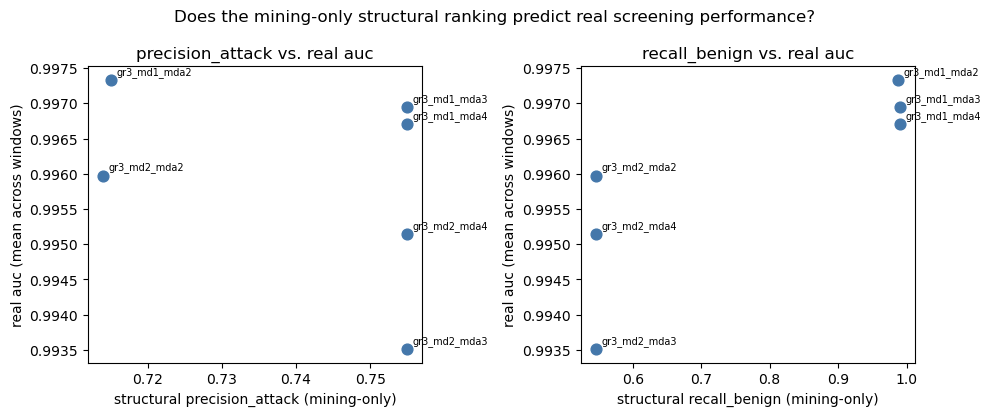

In [28]:
if joined.empty:
    print("Nothing to plot -- see the overlap warning above.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, (struct_col, real_col) in zip(axes, [("precision_attack", "auc_mean"), ("recall_benign", "auc_mean")]):
        ax.scatter(joined[struct_col], joined[real_col], s=60, color=LINE_COLOR)
        for _, r in joined.iterrows():
            ax.annotate(r["mining_setting"], (r[struct_col], r[real_col]), fontsize=7,
                        xytext=(4, 4), textcoords="offset points")
        ax.set_xlabel(f"structural {struct_col} (mining-only)")
        ax.set_ylabel("real auc (mean across windows)")
        ax.set_title(f"{struct_col} vs. real auc")
    fig.suptitle("Does the mining-only structural ranking predict real screening performance?")
    fig.tight_layout()

    print("\nmax_depth=1 vs max_depth=2 -- real auc:")
    print(joined.groupby("max_depth")[["auc_mean", "auc_std"]].mean().round(4))

    print("\nmax_depth_attack stability -- structural precision_attack_std vs real auc_std, "
          "averaged over max_depth:")
    print(joined.groupby("max_depth_attack")[["precision_attack_std", "auc_std"]].mean().round(4))

**Result**: 0/6 shortlist settings found -- this notebook is currently pointed at a
July 9th run made against the *old* single-tree grid (`gr3.0_md3` ... `gr5.0_md5`,
no `max_depth_attack` at all), which predates both the two-tree redesign and the
shortlist. Sections 1-4 above still ran cleanly against that old data (with a graceful
skip where names don't resolve, rather than crashing), but this section has nothing to
join until `run_screening_sweep.sh` is actually run against the current
`configs/screening_mining_settings.yaml` (the 6-entry shortlist) -- re-run this
notebook (or just this section) afterward to get the real comparison.

## 6. Baseline vs. symbolic: is the mined schema earning its keep?

Every window also has a `baseline` (`feature_set == "baseline"`) pass -- LogReg on
just the numeric base features, no mined schema at all. This joins each symbolic
`mining_setting`'s `auc`/`f1` back to its own window's baseline and computes the lift
directly per (granularity, window_id) pair -- not just comparing pooled means, which
would blend windows where baseline was already near-ceiling with windows where it
wasn't. Works on whatever grid this run evaluated, old or new, unlike section 5
above.

In [29]:
LIFT_METRICS = ["auc", "f1", "accuracy", "precision", "recall"]

baseline = per_window[per_window["feature_set"] == "baseline"][
    ["granularity", "window_id", *LIFT_METRICS]
].rename(columns={m: f"baseline_{m}" for m in LIFT_METRICS})

lift = symbolic.merge(baseline, on=["granularity", "window_id"], how="left")
for m in LIFT_METRICS:
    lift[f"{m}_lift"] = lift[m] - lift[f"baseline_{m}"]

lift_cols = [f"{m}_lift" for m in LIFT_METRICS]
# Grouped by (mining_setting, granularity), not mining_setting alone -- a
# setting's lift can differ by window size, so pooling across granularity
# would blend that away. This is also what lets section 6's plot below order
# boxes by granularity instead of by pooled lift.
lift_summary = lift.groupby(["mining_setting", "granularity"])[lift_cols].agg(["mean", "std"]).round(4)
lift_summary.columns = ["_".join(c) for c in lift_summary.columns.to_flat_index()]
lift_summary = lift_summary.sort_values("auc_lift_mean", ascending=False)
print(f"{(lift['auc_lift'] > 0).mean():.0%} of (setting, window) evaluations beat baseline on auc")
lift_summary

77% of (setting, window) evaluations beat baseline on auc


auc_lift_mean  auc_lift_std  f1_lift_mean  f1_lift_std  accuracy_lift_mean  accuracy_lift_std  precision_lift_mean  precision_lift_std  recall_lift_mean  recall_lift_std
mining_setting granularity                                                                                                                                                                           
gr3_md2_mda4   0.50                0.0008        0.0000        0.0481       0.0250              0.0022             0.0005               0.0723              0.0382            0.0045           0.0022
               0.25                0.0007        0.0004        0.0892       0.0519              0.0033             0.0018               0.1279              0.0779            0.0182           0.0338
gr3_md1_mda4   0.25                0.0007        0.0004        0.0891       0.0516              0.0033             0.0018               0.1277              0.0769            0.0180           0.0340
               0.50                0.0007        0.0001        0.0476       0.0255              0.0022             0.0006               0.0716              0.0389            0.0045           0.0022
gr3_md1_mda2   0.25                0.0005        0.0004        0.0510       0.0451              0.0019             0.0017               0.0670              0.0738            0.0177           0.0334
gr3_md1_mda3   0.25                0.0005        0.0004        0.0515       0.0449              0.0019             0.0017               0.0683              0.0742            0.0171           0.0321
gr3_md2_mda2   0.25                0.0005        0.0004        0.0507       0.0451              0.0019             0.0017               0.0667              0.0740            0.0175           0.0335
gr3_md2_mda4   0.20                0.0005        0.0006        0.0794       0.0416              0.0031             0.0014               0.1240              0.0647           -0.0054           0.0188
gr3_md2_mda3   0.25                0.0005        0.0005        0.0520       0.0450              0.0019             0.0017               0.0687              0.0744            0.0177           0.0329
gr3_md1_mda2   0.20                0.0004        0.0005        0.0490       0.0487              0.0021             0.0021               0.0802              0.0860           -0.0071           0.0173
gr3_md2_mda3   0.50                0.0004        0.0005        0.0384       0.0387              0.0016             0.0014               0.0573              0.0594            0.0043           0.0025
gr3_md2_mda2   0.50                0.0004        0.0003        0.0388       0.0414              0.0016             0.0015               0.0581              0.0639            0.0042           0.0021
gr3_md1_mda4   0.20                0.0004        0.0003        0.0797       0.0403              0.0031             0.0013               0.1243              0.0622           -0.0053           0.0189
gr3_md1_mda3   0.50                0.0004        0.0005        0.0369       0.0402              0.0016             0.0015               0.0550              0.0618            0.0045           0.0022
gr3_md1_mda2   0.50                0.0004        0.0004        0.0386       0.0414              0.0016             0.0015               0.0579              0.0639            0.0042           0.0021
gr3_md2_mda3   0.20                0.0004        0.0006        0.0624       0.0347              0.0025             0.0015               0.0993              0.0621           -0.0072           0.0172
gr3_md2_mda2   0.20                0.0003        0.0006        0.0479       0.0471              0.0021             0.0019               0.0780              0.0800           -0.0075           0.0170
gr3_md1_mda3   0.20                0.0003        0.0002        0.0625       0.0361              0.0024             0.0016               0.0993              0.0646           -0.0067           0.0175
gr3_md1_mda2   0.10               -0.0025        0.0101        0.049

In [ ]:
from matplotlib.transforms import blended_transform_factory

# Ordered by granularity (then mining_setting), not by pooled lift, so boxes
# at the same window size land next to each other for visibility.
order = (
    lift[["mining_setting", "granularity"]].drop_duplicates()
    .sort_values(["granularity", "mining_setting"])
    .itertuples(index=False, name=None)
)
order = list(order)
settings_only = [setting for setting, _ in order]
grans_only = [gran for _, gran in order]

# Contiguous (start, end, granularity) runs, 1-indexed to match boxplot
# positions -- used to draw group dividers and one granularity label per
# group, instead of repeating "g=..." on every single tick.
group_bounds = []
start = 1
for i in range(1, len(order) + 1):
    if i == len(order) or grans_only[i] != grans_only[i - 1]:
        group_bounds.append((start, i, grans_only[i - 1]))
        start = i + 1

fig, axes = plt.subplots(1, len(LIFT_METRICS), figsize=(4.2 * len(LIFT_METRICS), 4.5))
for i, (ax, m) in enumerate(zip(axes, LIFT_METRICS)):
    col = f"{m}_lift"
    data = [
        lift[(lift["mining_setting"] == setting) & (lift["granularity"] == gran)][col].dropna()
        for setting, gran in order
    ]
    ax.boxplot(data, tick_labels=settings_only)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")

    # symlog, not log: lift is signed (can cross zero), so a plain log scale is
    # invalid here. linthresh is set from this metric's own smallest non-zero
    # |lift| so the region around 0 -- where auc_lift in particular lives --
    # stays legible instead of being crushed by f1_lift's much larger range.
    finite = pd.concat(data)
    nonzero = finite[finite != 0].abs()
    linthresh = max(nonzero.min(), 1e-4) if not nonzero.empty else 1e-4
    ax.set_yscale("symlog", linthresh=linthresh)

    # group dividers between granularities, and one "g=..." label per group
    # drawn inside the axes (top, in data-x/axes-y blended coords) so it
    # doesn't need any extra figure margin to avoid being clipped.
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for _, end_pos, _ in group_bounds[:-1]:
        ax.axvline(end_pos + 0.5, color="#cccccc", linewidth=0.8, zorder=0)
    for start_pos, end_pos, gran in group_bounds:
        ax.text(
            (start_pos + end_pos) / 2, 0.97, f"g={gran:g}", transform=trans,
            ha="center", va="top", fontsize=8, fontweight="bold", color="#555555",
        )

    ax.set_ylabel("lift over baseline (symbolic - baseline, same window)" if i == 0 else "")
    ax.set_title(m)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)

fig.suptitle("Per-window metric lift over the no-symbolic baseline, by (mining_setting, granularity)")
fig.tight_layout(rect=[0, 0, 1, 0.94])

**Result** (on the old grid -- still useful as a sanity check of this section's own
logic, not a shortlist finding): `f1_lift` is consistently and substantially positive
(+0.050 to +0.076) across every setting, but `auc_lift` is slightly *negative* on
average for all nine (-0.003 to -0.007) despite 60% of individual (setting, window)
evaluations beating baseline on `auc`. Those two aren't contradictory: `auc_lift_std`
(0.006-0.016) is comparable to or larger than the mean itself, so a minority of windows
where the symbolic schema loses by a lot outweighs a majority of windows where it wins
by a little, on the mean -- the mined schema is reliably improving F1 (better
precision/recall balance on the minority attack class) without reliably improving AUC
(ranking quality) in this old data. Once the shortlist run exists, the same question is
worth re-asking specifically for `max_depth_attack=2` (the recommended pick) vs. `=3`/
`=4` -- section 5 above is where that comparison belongs once section 5's join has data.